# Prueba AB - Mejoras en la conversión

### 1. Cargar los datos. 

In [39]:
# cargar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

In [40]:
# cargar datasets

marketing_events = pd.read_csv('ab_project_marketing_events_us.csv')
ab_events = pd.read_csv('final_ab_events_upd_us.csv')
ab_new_users = pd.read_csv('final_ab_new_users_upd_us.csv')
ab_participants = pd.read_csv('final_ab_participants_upd_us.csv')

### 2. Visualización inicial de los datos

Se realiza la creación de una función para hacer la visualización inicial de los datos de una manera mucho más rapida.

In [41]:
def info_from_df(df):
    print(df.info())
    print("Cantidad de valores nulos por columna:")
    print(df.isnull().sum())
    print("Cantidad de filas duplicadas:")
    print(df.duplicated().sum())

In [42]:
df_list = [marketing_events, ab_events, ab_new_users, ab_participants]
for df in df_list:
    info_from_df(df)

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       14 non-null     str  
 1   regions    14 non-null     str  
 2   start_dt   14 non-null     str  
 3   finish_dt  14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes
None
Cantidad de valores nulos por columna:
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64
Cantidad de filas duplicadas:
0
<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  str    
 1   event_dt    423761 non-null  str    
 2   event_name  423761 non-null  str    
 3   details     60314 non-null   float64
dtypes: float64(1), str(3)
memory usage: 12.9 MB
None
Cantidad de valores nulos por columna:
user_id            0
event_dt           0
event

Es necesario hacer la conversión de datos para algunos dataframes con una función también. 

In [43]:
def change_date_format(df, column_name):
    for col in column_name:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    
    return df


In [44]:
marketing_events = change_date_format(marketing_events, ['start_dt','finish_dt'])
ab_events = change_date_format(ab_events, ['event_dt'])
ab_new_users = change_date_format(ab_new_users, ['first_date'])

Se debe realizar un filtro que cumpla con el requisito del estudio dentro de los 14 días posteriores. 

In [45]:
# Unir eventos con usuarios para saber su fecha de registro
ab_events_filtered = ab_events.merge(ab_new_users[['user_id', 'first_date']], on='user_id', how='inner')

# Calcular días desde registro hasta el evento
ab_events_filtered['days_since_register'] = (
    ab_events_filtered['event_dt'] - ab_events_filtered['first_date']
).dt.days

# Quedarnos solo con eventos dentro de los primeros 14 días
ab_events_filtered = ab_events_filtered[
    (ab_events_filtered['days_since_register'] >= 0) &
    (ab_events_filtered['days_since_register'] <= 14)
]

print('Eventos totales:', len(ab_events))
print(f'Eventos removidos: {len(ab_events_filtered) - len(ab_events_clean)}')
print('Eventos dentro de 14 días:', len(ab_events_filtered))

Eventos totales: 423761
Eventos removidos: 2627
Eventos dentro de 14 días: 410214


### 3. Inicio de la conexión de los datos. 

Se hace una función que facilita la operación de la conversión por evento. 

In [46]:
def get_conversion(df_eventos, df_pruebas, ab_test):
  if ab_test == None:
    result_df = df_eventos.merge(df_pruebas, on="user_id", how="inner")
  else:
    df_pruebas = df_pruebas[df_pruebas["ab_test"] == ab_test]
    result_df = df_eventos.merge(df_pruebas, on="user_id", how="inner")
  
  result_df = result_df[result_df["event_name"] != "login"]
  summary = pd.pivot_table(result_df, columns="event_name", index="group", aggfunc=pd.Series.nunique)["user_id"]
  summary = summary.reset_index()
  summary = summary[["group", "product_page", "product_cart", "purchase"]]
  summary["conversion_rate"] = summary["purchase"] / summary["product_page"]
  return summary

In [47]:
get_conversion(ab_events_filtered, ab_participants, None)

event_name,group,product_page,product_cart,purchase,conversion_rate
0,A,5207,2483,2682,0.515076
1,B,3985,2037,2008,0.503890


La tasa de conversión es muy baja, lo que es común en este tipo de pruebas. Sin embargo, la diferencia entre ambas es mínima, adicionalmente, se muestra una anomalía en el grupo A, pues no debería haber más purchase que productos añadidos en el carro. 

In [48]:
def get_conversion_by_event(summary):
    summary["conversion_rate_product_cart"] = summary["product_cart"] / summary["product_page"]
    summary["conversion_rate_purchase"] = summary["purchase"] / summary["product_cart"]
    return summary[['group','conversion_rate', 'conversion_rate_product_cart', 'conversion_rate_purchase']]

Se realiza una función para obtener la conversión por etapa/evento. 

In [49]:
summary = get_conversion(ab_events_filtered, ab_participants, None)
total_conversions = get_conversion_by_event(summary)
total_conversions

event_name,group,conversion_rate,conversion_rate_product_cart,conversion_rate_purchase
0,A,0.515076,0.476858,1.080145
1,B,0.503890,0.511167,0.985763


Se realiza una nueva función, para revisar esta distribución de numero de eventos por usuario.

In [50]:
def number_of_events(df_eventos, df_pruebas, ab_test):
  if ab_test == None:
    result_df = df_eventos.merge(df_pruebas, on="user_id", how="inner")
  else:
    df_pruebas = df_pruebas[df_pruebas["ab_test"] == ab_test]
    result_df = df_eventos.merge(df_pruebas, on="user_id", how="inner")
  
  number = result_df.groupby(["user_id", "group"])["event_name"].count().reset_index()
  A_count = number[number["group"] == "A"]["event_name"].mean()
  B_count = number[number["group"] == "B"]["event_name"].mean()
  return A_count, B_count

In [51]:
number_of_events(ab_events, ab_participants, None)

(np.float64(7.455549911099822), np.float64(7.11248992747784))

Confirmación de usuarios presentes en ambas muestras:

In [52]:
# Usuarios por grupo
usuarios_A = set(ab_participants[ab_participants['group'] == 'A']['user_id'])
usuarios_B = set(ab_participants[ab_participants['group'] == 'B']['user_id'])

# Usuarios en ambos grupos
usuarios_ambos = usuarios_A & usuarios_B

print('Usuarios solo en A:', len(usuarios_A))
print('Usuarios solo en B:', len(usuarios_B))
print('Usuarios en ambos grupos:', len(usuarios_ambos))

Usuarios solo en A: 7874
Usuarios solo en B: 6205
Usuarios en ambos grupos: 441


Distribución de los usuarios. ¿Es equitativa?

In [53]:
A_count, B_count = number_of_events(ab_events_filtered, ab_participants, None)

print(f'Promedio eventos por usuario - Grupo A: {A_count:.2f}')
print(f'Promedio eventos por usuario - Grupo B: {B_count:.2f}')
print(f'Diferencia: {abs(A_count - B_count):.2f}')

Promedio eventos por usuario - Grupo A: 7.26
Promedio eventos por usuario - Grupo B: 6.88
Diferencia: 0.38


- Se encontraron **441** usuarios presentes en ambos grupos, 
lo que representa una contaminación en la prueba. Estos usuarios deben 
eliminarse del análisis ya que recibieron ambos tratamientos y pueden 
sesgar los resultados.

-  El promedio de eventos por usuario es similar entre 
ambos grupos (**A: 7.26** vs **B: 6.88**), con una diferencia de solo 
0.38 eventos. Esto indica que la distribución es bastante equitativa 
y no representa un problema para la prueba.

Toca hacer una limpieza de los datos para hacer la prueba:

In [54]:

ab_participants_clean = ab_participants[
    ~ab_participants['user_id'].isin(usuarios_ambos)
]

ab_events_clean = ab_events_filtered[
    ~ab_events_filtered['user_id'].isin(usuarios_ambos)
]

print('Participantes tras limpieza:', len(ab_participants_clean))

Participantes tras limpieza: 13643


In [55]:
# Volver a correr conversiones con datos limpios
summary = get_conversion(ab_events_clean, ab_participants_clean, None)
total_conversions = get_conversion_by_event(summary)
display(total_conversions)

event_name,group,conversion_rate,conversion_rate_product_cart,conversion_rate_purchase
0,A,0.517626,0.477512,1.084005
1,B,0.506462,0.514540,0.984301


### 4. Prueba Z - Resultados de la prueba AB

Se verifica si el grupo B (nuevo sistema de recomendaciones) 
mejoró significativamente la conversión en cada etapa del embudo.

- **H₀:** No hay diferencia entre grupos A y B
- **H₁:** El grupo B tiene mayor conversión que el grupo A
- **Nivel de significancia:** 5% (alpha = 0.05)

In [56]:
# Total de usuarios por grupo (no product_page)
total_A = len(ab_participants_clean[ab_participants_clean['group'] == 'A'])
total_B = len(ab_participants_clean[ab_participants_clean['group'] == 'B'])

# Create summary_clean with the cleaned data
summary_clean = get_conversion(ab_events_clean, ab_participants_clean, None)

eventos = ['product_page', 'product_cart', 'purchase']

for evento in eventos:

    conv_A = summary_clean[summary_clean['group'] == 'A'][evento].values[0]
    conv_B = summary_clean[summary_clean['group'] == 'B'][evento].values[0]

    count = [conv_B, conv_A]
    nobs  = [total_B, total_A]

    z, p = proportions_ztest(count, nobs)

    print(f'Evento: {evento}')
    print(f'  Conversión A: {conv_A/total_A:.4f} | Conversión B: {conv_B/total_B:.4f}')
    print(f'  p-value: {p:.4f}')

    if p < 0.05:
        print('Rechazamos H₀ — hay diferencia significativa')
    else:
        print('No rechazamos H₀ — no hay diferencia significativa')
    print()

Evento: product_page
  Conversión A: 0.6350 | Conversión B: 0.6327
  p-value: 0.7815
No rechazamos H₀ — no hay diferencia significativa

Evento: product_cart
  Conversión A: 0.3032 | Conversión B: 0.3256
  p-value: 0.0054
Rechazamos H₀ — hay diferencia significativa

Evento: purchase
  Conversión A: 0.3287 | Conversión B: 0.3204
  p-value: 0.3079
No rechazamos H₀ — no hay diferencia significativa



El nuevo sistema de recomendaciones (Grupo B) solo mejora una etapa del embudo, pero no aumenta las compras finales. Se puede ver que:

Product Page: No hay diferencia, el interés inicial es igual en ambos grupos.
Product Cart: Grupo B mejora significativamente, más usuarios añaden productos al carrito.
Purchase: No hay diferencia, la mejora en carritos no se traduce en ventas.

El sistema de recomendaciones sí aumenta la intención de compra, pero el problema está en el checkout.
Se deben enfocar próximos experimentos en optimizar la etapa final del embudo.

### 5. Distribución en tre los días. 

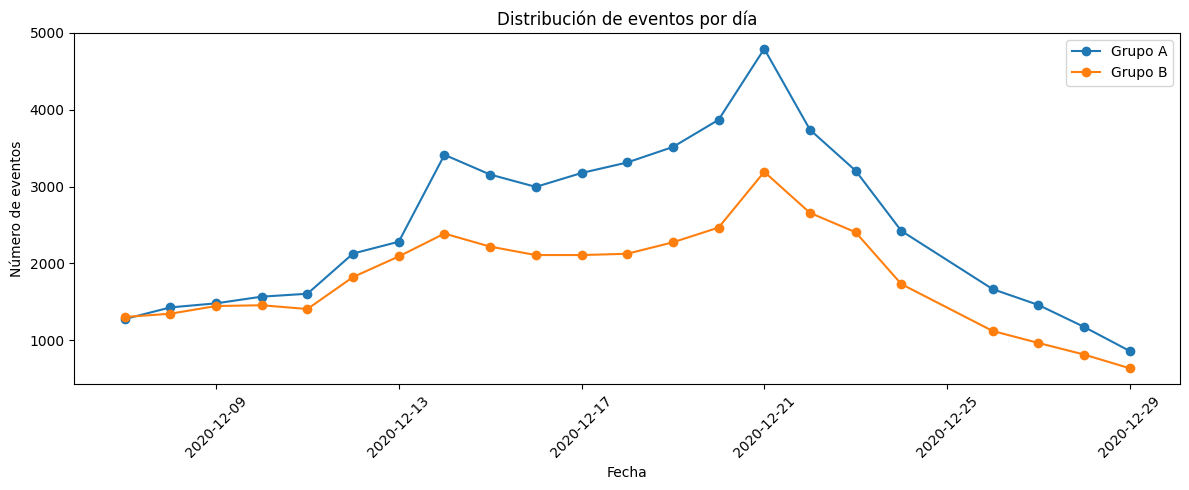

In [57]:
# Extraer solo la fecha sin hora
ab_events_clean['date_only'] = ab_events_clean['event_dt'].dt.date

events_by_day = (ab_events_clean
                 .merge(ab_participants_clean[['user_id', 'group']], on='user_id')
                 .groupby(['date_only', 'group'])['event_name']
                 .count()
                 .reset_index())

events_by_day.columns = ['fecha', 'grupo', 'eventos']

# grafico de eventos por día y grupo
plt.figure(figsize=(12, 5))
for grupo in ['A', 'B']:
    data = events_by_day[events_by_day['grupo'] == grupo]
    plt.plot(data['fecha'], data['eventos'], marker='o', label=f'Grupo {grupo}')

plt.title('Distribución de eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

 La distribución de eventos por día revela dos patrones importantes:

- Ambos grupos siguen la misma tendencia general, con un pico 
  el **21 de diciembre** y una caída hacia fin de año, lo que 
  coincide con las fiestas de navidad.

- El **Grupo A** tiene consistentemente más eventos que el **Grupo B** 
  durante toda la prueba, lo que confirma que los grupos no eran 
  del mismo tamaño (A: 7,874 vs B: 6,205 usuarios).

- La caída después del 21 de diciembre es natural ya que esa fue 
  la fecha límite para aceptar nuevos usuarios, por lo que 
  la actividad empieza a reducirse gradualmente.

- No se observan días atípicos o anomalías que pudieran 
  contaminar los resultados de la prueba.

## Conclusiones Generales

Sobre la prueba:

Se detectaron 441 usuarios contaminados en ambos grupos, que fueron eliminados del análisis.
La distribución de eventos entre grupos fue equilibrada
(A: 7.26 vs B: 6.88 eventos promedio).

Sobre los resultados:

El nuevo sistema de recomendaciones mejoró de forma significativa la conversión en product_cart según la prueba Z.
Sin embargo, product_page y purchase no mostraron diferencias significativas entre grupos.
La mejora en carritos no se refleja en un aumento de compras finales.

Recomendación:
No se recomienda implementar el nuevo sistema de recomendaciones como solución completa.
Se sugiere mantenerlo como parte de pruebas adicionales y enfocar esfuerzos en optimizar la etapa entre product_cart y purchase, donde se pierde el impulso generado por las recomendaciones.